In [ ]:
from google.colab import files
files.upload()  # kaggle.json 업로드

In [18]:
!pip install -U kaggle

In [24]:
!mkdir -p /root/.kaggle
!cp "kaggle (1).json" /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

In [25]:
import os
os.environ['KAGGLE_CONFIG_DIR'] = '/root/.kaggle'

In [ ]:
!ls /root/.kaggle
!cat /root/.kaggle/kaggle.json
!kaggle config view

In [27]:
!kaggle competitions download -c deepfake-detection-challenge
!unzip "*.zip"

100% 4.13G/4.13G [00:26<00:00, 169MB/s]

Archive:  deepfake-detection-challenge.zip
  inflating: sample_submission.csv   
  inflating: test_videos/aassnaulhq.mp4  
  inflating: test_videos/aayfryxljh.mp4  
  inflating: test_videos/acazlolrpz.mp4  
  inflating: test_videos/adohdulfwb.mp4  
  inflating: test_videos/ahjnxtiamx.mp4  
  inflating: test_videos/ajiyrjfyzp.mp4  
  inflating: test_videos/aktnlyqpah.mp4  
  inflating: test_videos/alrtntfxtd.mp4  
  inflating: test_videos/aomqqjipcp.mp4  
  inflating: test_videos/apedduehoy.mp4  
  inflating: test_videos/apvzjkvnwn.mp4  
  inflating: test_videos/aqrsylrzgi.mp4  
  inflating: test_videos/axfhbpkdlc.mp4  
  inflating: test_videos/ayipraspbn.mp4  
  inflating: test_videos/bcbqxhziqz.mp4  
  inflating: test_videos/bcvheslzrq.mp4  
  inflating: test_videos/bdshuoldwx.mp4  
  inflating: test_videos/bfdopzvxbi.mp4  
  inflating: test_videos/bfjsthfhbd.mp4  
  inflating: test_videos/bjyaxvggle.mp4  
  inflating: test_videos/bkcyglmfci.mp

In [28]:
import os
import cv2
import json

video_dir = "train_sample_videos"
frame_root = "frames"
os.makedirs(frame_root, exist_ok=True)

# metadata 로드
with open(os.path.join(video_dir, "metadata.json")) as f:
    meta = json.load(f)

for video_name in list(meta.keys())[:50]:  # 일단 50개만
    label = meta[video_name]["label"]

    video_path = os.path.join(video_dir, video_name)
    save_dir = os.path.join(frame_root, label, video_name[:-4])
    os.makedirs(save_dir, exist_ok=True)

    cap = cv2.VideoCapture(video_path)
    idx = 0
    saved = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if idx % 30 == 0:  # 30프레임마다 저장
            cv2.imwrite(f"{save_dir}/frame_{saved}.jpg", frame)
            saved += 1

        idx += 1

    cap.release()

print("완료")

완료


In [29]:
import glob

frame_list = glob.glob("frames/*/*/*.jpg")
print("추출된 프레임 수:", len(frame_list))
print("예시:", frame_list[:5])

추출된 프레임 수: 500
예시: ['frames/FAKE/aapnvogymq/frame_0.jpg', 'frames/FAKE/aapnvogymq/frame_8.jpg', 'frames/FAKE/aapnvogymq/frame_6.jpg', 'frames/FAKE/aapnvogymq/frame_1.jpg', 'frames/FAKE/aapnvogymq/frame_2.jpg']


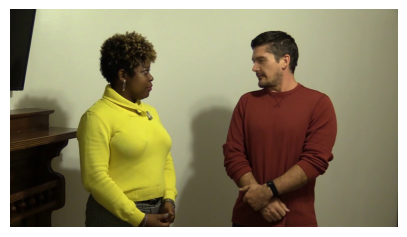

In [30]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(frame_list[0])
plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.show()

In [31]:
!pip install mediapipe

In [40]:
import os
import cv2
import glob
import numpy as np

input_root = "frames"
output_root = "roi_frames"
os.makedirs(output_root, exist_ok=True)

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

frame_files = glob.glob(os.path.join(input_root, "*", "*", "*.jpg"))
print("전체 프레임 수:", len(frame_files))

count_ok = 0
count_fail = 0

for frame_path in frame_files:
    img = cv2.imread(frame_path)
    if img is None:
        count_fail += 1
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=3,
        minSize=(50, 50)
    )

    if len(faces) == 0:
        count_fail += 1
        continue

    # 가장 큰 얼굴 선택
    x, y, w, h = max(faces, key=lambda f: f[2] * f[3])

    face_crop = img[y:y+h, x:x+w]
    fh, fw = face_crop.shape[:2]

    # 마스크 생성
    mask = np.zeros((fh, fw), dtype=np.uint8)

    # 1) 얼굴 외곽 경계면: 타원형 얼굴 마스크 - 안쪽 타원
    center = (fw // 2, fh // 2)
    axes_outer = (int(fw * 0.48), int(fh * 0.48))
    axes_inner = (int(fw * 0.38), int(fh * 0.38))

    outer = np.zeros((fh, fw), dtype=np.uint8)
    inner = np.zeros((fh, fw), dtype=np.uint8)

    cv2.ellipse(outer, center, axes_outer, 0, 0, 360, 255, -1)
    cv2.ellipse(inner, center, axes_inner, 0, 0, 360, 255, -1)

    boundary_ring = cv2.subtract(outer, inner)

    # 2) 입 주변부: 얼굴 비율 기준 입 위치 추정
    mouth_x1 = int(fw * 0.30)
    mouth_x2 = int(fw * 0.70)
    mouth_y1 = int(fh * 0.62)
    mouth_y2 = int(fh * 0.82)

    mouth_mask = np.zeros((fh, fw), dtype=np.uint8)
    cv2.rectangle(mouth_mask, (mouth_x1, mouth_y1), (mouth_x2, mouth_y2), 255, -1)

    # 입 내부 깎아서 주변부만 남기기
    mouth_inner = np.zeros((fh, fw), dtype=np.uint8)
    cv2.rectangle(
        mouth_inner,
        (int(fw * 0.36), int(fh * 0.67)),
        (int(fw * 0.64), int(fh * 0.77)),
        255,
        -1
    )

    mouth_ring = cv2.subtract(mouth_mask, mouth_inner)

    # 최종 마스크 = 얼굴 경계면 + 입 주변부
    final_mask = cv2.bitwise_or(boundary_ring, mouth_ring)

    # 마스크 적용
    roi_img = cv2.bitwise_and(face_crop, face_crop, mask=final_mask)

    # 너무 비어 있으면 실패 처리
    if np.count_nonzero(final_mask) < 500:
        count_fail += 1
        continue

    roi_img = cv2.resize(roi_img, (224, 224))

    rel_path = os.path.relpath(frame_path, input_root)
    save_path = os.path.join(output_root, rel_path)
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    cv2.imwrite(save_path, roi_img)
    count_ok += 1

print("성공:", count_ok)
print("실패:", count_fail)

전체 프레임 수: 500
성공: 478
실패: 22


ROI 이미지 수: 478
예시: ['roi_frames/FAKE/aapnvogymq/frame_0.jpg', 'roi_frames/FAKE/aapnvogymq/frame_8.jpg', 'roi_frames/FAKE/aapnvogymq/frame_6.jpg', 'roi_frames/FAKE/aapnvogymq/frame_1.jpg', 'roi_frames/FAKE/aapnvogymq/frame_2.jpg']


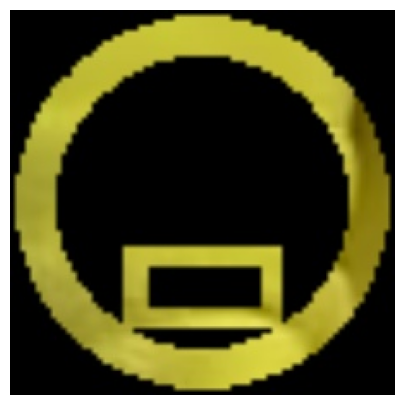

In [41]:
import glob
from PIL import Image
import matplotlib.pyplot as plt

roi_list = glob.glob("roi_frames/*/*/*.jpg")
print("ROI 이미지 수:", len(roi_list))
print("예시:", roi_list[:5])

img = Image.open(roi_list[0])
plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.show()

In [42]:
!rm -rf dataset_split

In [43]:
import os
import glob
import random
import shutil

random.seed(42)

src_root = "roi_frames"
dst_root = "dataset_split"
classes = ["REAL", "FAKE"]
split_ratio = 0.8

for cls in classes:
    files = glob.glob(os.path.join(src_root, cls, "*", "*.jpg"))
    print(f"{cls} 원본 개수:", len(files))

    random.shuffle(files)
    split_idx = int(len(files) * split_ratio)

    train_files = files[:split_idx]
    val_files = files[split_idx:]

    for split_name, split_files in [("train", train_files), ("val", val_files)]:
        save_dir = os.path.join(dst_root, split_name, cls)
        os.makedirs(save_dir, exist_ok=True)

        for i, file_path in enumerate(split_files):
            new_name = f"{cls.lower()}_{i:05d}.jpg"
            shutil.copy(file_path, os.path.join(save_dir, new_name))

        print(f"{split_name}/{cls}:", len(split_files))

print("분할 완료")

REAL 원본 개수: 66
train/REAL: 52
val/REAL: 14
FAKE 원본 개수: 412
train/FAKE: 329
val/FAKE: 83
분할 완료


In [44]:
!find dataset_split/train/REAL -type f | wc -l
!find dataset_split/train/FAKE -type f | wc -l
!find dataset_split/val/REAL -type f | wc -l
!find dataset_split/val/FAKE -type f | wc -l

52
329
14
83


In [45]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder("dataset_split/train", transform=transform)
val_dataset = datasets.ImageFolder("dataset_split/val", transform=transform)

print("클래스:", train_dataset.classes)
print("train 개수:", len(train_dataset))
print("val 개수:", len(val_dataset))

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

model = models.resnet18(weights="DEFAULT")
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

device: cuda
클래스: ['FAKE', 'REAL']
train 개수: 381
val 개수: 97
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 197MB/s]


In [46]:
num_epochs = 5
best_val_acc = 0.0

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (preds == labels).sum().item()

    train_acc = train_correct / train_total

    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (preds == labels).sum().item()

    val_acc = val_correct / val_total

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss/len(train_loader):.4f} | "
          f"Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss/len(val_loader):.4f} | "
          f"Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_resnet18_roi.pth")
        print("best 모델 저장 완료")

Epoch 1/5 | Train Loss: 0.4184 | Train Acc: 0.8058 | Val Loss: 0.2740 | Val Acc: 0.9175
best 모델 저장 완료
Epoch 2/5 | Train Loss: 0.0976 | Train Acc: 0.9764 | Val Loss: 0.1184 | Val Acc: 0.9381
best 모델 저장 완료
Epoch 3/5 | Train Loss: 0.0324 | Train Acc: 0.9974 | Val Loss: 0.0828 | Val Acc: 0.9794
best 모델 저장 완료
Epoch 4/5 | Train Loss: 0.0356 | Train Acc: 0.9869 | Val Loss: 0.1757 | Val Acc: 0.9278
Epoch 5/5 | Train Loss: 0.0458 | Train Acc: 0.9869 | Val Loss: 0.1500 | Val Acc: 0.9485


In [47]:
torch.save(model.state_dict(), "last_resnet18_roi.pth")
print("마지막 모델 저장 완료")
print("최고 검증 정확도:", best_val_acc)

마지막 모델 저장 완료
최고 검증 정확도: 0.979381443298969


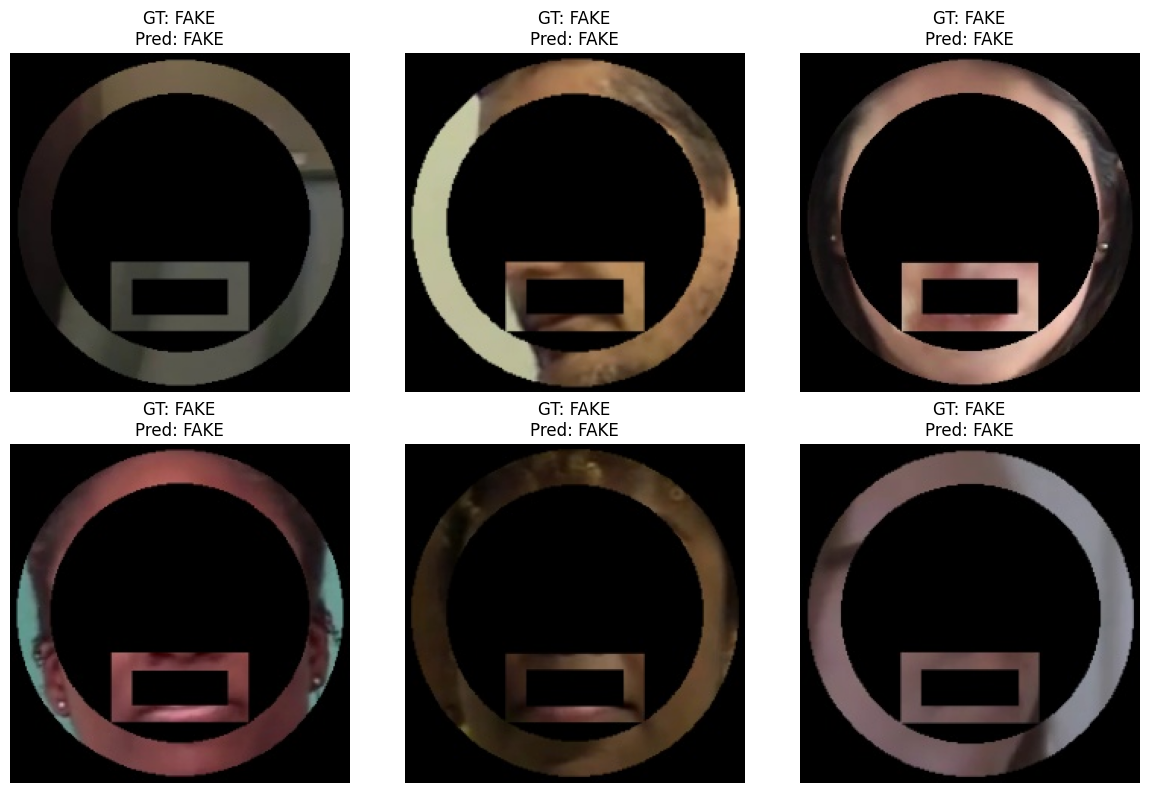

In [48]:
import matplotlib.pyplot as plt
import numpy as np

idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}

model.load_state_dict(torch.load("best_resnet18_roi.pth"))
model.eval()

images, labels = next(iter(val_loader))
images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

images_cpu = images.cpu()
labels_cpu = labels.cpu()
preds_cpu = preds.cpu()

plt.figure(figsize=(12, 8))
for i in range(min(6, len(images_cpu))):
    img = images_cpu[i].permute(1, 2, 0).numpy()
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(f"GT: {idx_to_class[labels_cpu[i].item()]}\nPred: {idx_to_class[preds_cpu[i].item()]}")
    plt.axis("off")
plt.tight_layout()
plt.show()